In [14]:
import torch
print("PyTorch MPS available:", torch.backends.mps.is_available())

from ultralytics import YOLO
print("YOLO imported successfully")

import os
import matplotlib.pyplot as plt
import cv2


PyTorch MPS available: True
YOLO imported successfully


In [2]:
# Cell 1 — environment check + optional installs
import sys, platform
print("Python:", sys.version.splitlines()[0])
print("Platform:", platform.platform())

# Optional: install packages if not present. Uncomment to run.
# Note: on macOS M4 pip will pull wheels for arm64 where available.
# !pip install --upgrade pip
# !pip install ultralytics opencv-python-headless matplotlib pandas tqdm pycocotools lxml pillow scikit-learn

# Quick import test
import importlib
for pkg in ("ultralytics","cv2","matplotlib","pandas","tqdm"):
    try:
        m = importlib.import_module(pkg)
        print(f"{pkg} OK, version:", getattr(m, "__version__", "unknown"))
    except Exception as e:
        print(f"{pkg} NOT FOUND ({e})")


Python: 3.10.19 (main, Oct 21 2025, 16:37:10) [Clang 20.1.8 ]
Platform: macOS-26.1-arm64-arm-64bit
ultralytics OK, version: 8.3.228
cv2 OK, version: 4.12.0
matplotlib OK, version: 3.10.7
pandas OK, version: 2.3.3
tqdm OK, version: 4.67.1


In [2]:
from pathlib import Path

# ❗ EDIT THIS PATH — point to your dataset folder
DATA_DIR = Path("/Users/satvikpandey/Downloads/central university of jammu/end sem project/animal image dataset")

assert DATA_DIR.exists(), f"Dataset folder not found: {DATA_DIR}"
print("Dataset directory:", DATA_DIR)

Dataset directory: /Users/satvikpandey/Downloads/central university of jammu/end sem project/animal image dataset


In [3]:
from collections import Counter

def scan_dataset(root: Path):
    exts = Counter()
    files_by_ext = {}
    for p in root.rglob("*"):
        if p.is_file():
            ext = p.suffix.lower()
            exts[ext] += 1
            files_by_ext.setdefault(ext, []).append(p)
    return exts, files_by_ext

exts, files_by_ext = scan_dataset(DATA_DIR)

print("📦 FILE TYPES FOUND:")
for ext, count in exts.most_common():
    print(f"  {ext or '[no extension]'} : {count}")

print("\n📸 IMAGE EXTENSIONS FOUND:", [e for e in exts if e in [".jpg", ".jpeg", ".png"]])
print("📝 LABEL EXTENSIONS FOUND:", [e for e in exts if e in [".txt", ".xml", ".json", ".csv"]])

# preview example files
for e in (".jpg", ".png", ".txt", ".xml", ".json", ".csv"):
    if e in files_by_ext:
        print(f"\nExample {e} file:")
        print(files_by_ext[e][0])


📦 FILE TYPES FOUND:
  .jpg : 29071
  .txt : 29071
  [no extension] : 3

📸 IMAGE EXTENSIONS FOUND: ['.jpg']
📝 LABEL EXTENSIONS FOUND: ['.txt']

Example .jpg file:
/Users/satvikpandey/Downloads/central university of jammu/end sem project/animal image dataset/test/Hippopotamus/1961560b640effba.jpg

Example .txt file:
/Users/satvikpandey/Downloads/central university of jammu/end sem project/animal image dataset/test/Hippopotamus/Label/07938a3ec06e26af.txt


Matplotlib is building the font cache; this may take a moment.


Found images: 29071


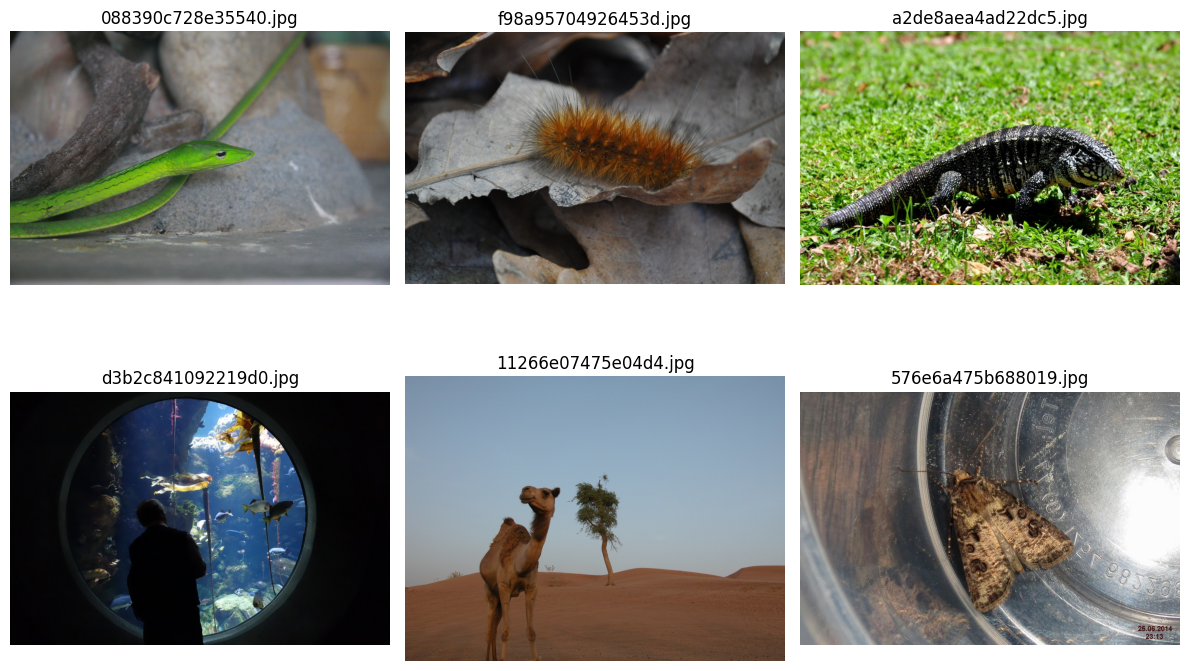

In [4]:
import random
import matplotlib.pyplot as plt
import cv2

# Collect all images
image_paths = []
for ext in [".jpg", ".jpeg", ".png"]:
    if ext in files_by_ext:
        image_paths += files_by_ext[ext]

print("Found images:", len(image_paths))

samples = random.sample(image_paths, min(6, len(image_paths)))

plt.figure(figsize=(12,8))
for i, img_path in enumerate(samples, 1):
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i)
    plt.imshow(img)
    plt.title(img_path.name)
    plt.axis("off")
plt.tight_layout()
plt.show()


In [5]:
from pathlib import Path

dataset_root = DATA_DIR  # your dataset folder

all_pairs = []

for class_dir in dataset_root.rglob("*"):
    if class_dir.is_dir() and not class_dir.name.lower().startswith("label"):
        imgs = list(class_dir.glob("*.jpg"))
        label_dir = class_dir / "Label"
        if not label_dir.exists(): 
            continue
        txts = list(label_dir.glob("*.txt"))

        # If number of labels == number of images, assume 1:1 mapping by index
        if len(imgs) == len(txts):
            imgs_sorted = sorted(imgs)
            txts_sorted = sorted(txts)
            for img, txt in zip(imgs_sorted, txts_sorted):
                all_pairs.append((img, txt))
        else:
            print("⚠️ WARNING: mismatch in", class_dir)
            print("Images:", len(imgs), "Labels:", len(txts))

print("Total pairs found:", len(all_pairs))


Total pairs found: 29071


In [6]:
from pathlib import Path
import shutil

OUT_DIR = Path(DATA_DIR.parent / "yolo_dataset")   # saves alongside your dataset
print("Creating YOLOv8 dataset at:", OUT_DIR)

# Create directory structure
for sub in ["images/train", "images/val", "images/test",
            "labels/train", "labels/val", "labels/test"]:
    (OUT_DIR / sub).mkdir(parents=True, exist_ok=True)

Creating YOLOv8 dataset at: /Users/satvikpandey/Downloads/central university of jammu/end sem project/yolo_dataset


In [8]:
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 6.3 MB/s  0:00:01m 6.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]


In [9]:
from sklearn.model_selection import train_test_split

pairs = all_pairs  # from earlier

train_pairs, test_pairs = train_test_split(pairs, test_size=0.1, random_state=42)
train_pairs, val_pairs = train_test_split(train_pairs, test_size=0.1111, random_state=42)  
# ≈ 80 / 10 / 10

print(
    "Train:", len(train_pairs),
    "Val:", len(val_pairs),
    "Test:", len(test_pairs)
)

Train: 23256 Val: 2907 Test: 2908


In [10]:
def copy_pairs(pairs, img_out, lbl_out):
    for img_path, lbl_path in pairs:
        # destination image path
        dest_img = OUT_DIR / img_out / img_path.name
        shutil.copy2(img_path, dest_img)

        # destination label must have same filename as image but .txt
        dest_lbl = OUT_DIR / lbl_out / (img_path.stem + ".txt")
        shutil.copy2(lbl_path, dest_lbl)

copy_pairs(train_pairs, "images/train", "labels/train")
copy_pairs(val_pairs,   "images/val",   "labels/val")
copy_pairs(test_pairs,  "images/test",  "labels/test")

print("Dataset successfully copied to YOLO format.")


Dataset successfully copied to YOLO format.


In [12]:
classes = sorted(list({p[0].parent.name for p in all_pairs}))
print("Detected classes:", len(classes))
classes

Detected classes: 80


['Bear',
 'Brown bear',
 'Bull',
 'Butterfly',
 'Camel',
 'Canary',
 'Caterpillar',
 'Cattle',
 'Centipede',
 'Cheetah',
 'Chicken',
 'Crab',
 'Crocodile',
 'Deer',
 'Duck',
 'Eagle',
 'Elephant',
 'Fish',
 'Fox',
 'Frog',
 'Giraffe',
 'Goat',
 'Goldfish',
 'Goose',
 'Hamster',
 'Harbor seal',
 'Hedgehog',
 'Hippopotamus',
 'Horse',
 'Jaguar',
 'Jellyfish',
 'Kangaroo',
 'Koala',
 'Ladybug',
 'Leopard',
 'Lion',
 'Lizard',
 'Lynx',
 'Magpie',
 'Monkey',
 'Moths and butterflies',
 'Mouse',
 'Mule',
 'Ostrich',
 'Otter',
 'Owl',
 'Panda',
 'Parrot',
 'Penguin',
 'Pig',
 'Polar bear',
 'Rabbit',
 'Raccoon',
 'Raven',
 'Red panda',
 'Rhinoceros',
 'Scorpion',
 'Sea lion',
 'Sea turtle',
 'Seahorse',
 'Shark',
 'Sheep',
 'Shrimp',
 'Snail',
 'Snake',
 'Sparrow',
 'Spider',
 'Squid',
 'Squirrel',
 'Starfish',
 'Swan',
 'Tick',
 'Tiger',
 'Tortoise',
 'Turkey',
 'Turtle',
 'Whale',
 'Woodpecker',
 'Worm',
 'Zebra']

In [21]:
# Build class name list from your dataset directories
classes = sorted({img.parent.name for img, txt in all_pairs})
class_to_id = {c:i for i, c in enumerate(classes)}

print(class_to_id)
print("Total classes:", len(class_to_id))


{'Bear': 0, 'Brown bear': 1, 'Bull': 2, 'Butterfly': 3, 'Camel': 4, 'Canary': 5, 'Caterpillar': 6, 'Cattle': 7, 'Centipede': 8, 'Cheetah': 9, 'Chicken': 10, 'Crab': 11, 'Crocodile': 12, 'Deer': 13, 'Duck': 14, 'Eagle': 15, 'Elephant': 16, 'Fish': 17, 'Fox': 18, 'Frog': 19, 'Giraffe': 20, 'Goat': 21, 'Goldfish': 22, 'Goose': 23, 'Hamster': 24, 'Harbor seal': 25, 'Hedgehog': 26, 'Hippopotamus': 27, 'Horse': 28, 'Jaguar': 29, 'Jellyfish': 30, 'Kangaroo': 31, 'Koala': 32, 'Ladybug': 33, 'Leopard': 34, 'Lion': 35, 'Lizard': 36, 'Lynx': 37, 'Magpie': 38, 'Monkey': 39, 'Moths and butterflies': 40, 'Mouse': 41, 'Mule': 42, 'Ostrich': 43, 'Otter': 44, 'Owl': 45, 'Panda': 46, 'Parrot': 47, 'Penguin': 48, 'Pig': 49, 'Polar bear': 50, 'Rabbit': 51, 'Raccoon': 52, 'Raven': 53, 'Red panda': 54, 'Rhinoceros': 55, 'Scorpion': 56, 'Sea lion': 57, 'Sea turtle': 58, 'Seahorse': 59, 'Shark': 60, 'Sheep': 61, 'Shrimp': 62, 'Snail': 63, 'Snake': 64, 'Sparrow': 65, 'Spider': 66, 'Squid': 67, 'Squirrel': 68, 

In [22]:
import cv2
from pathlib import Path

def convert_label(old_txt_path, img_path, save_to):
    """
    Reads old VOC-format labels:
      Class xmin ymin xmax ymax
    Converts to YOLO format:
      class_id x_center y_center width height  (all normalized)
    """
    H, W = cv2.imread(str(img_path)).shape[:2]

    new_lines = []
    with open(old_txt_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 5:
                continue

            cls_name = parts[0]
            xmin, ymin, xmax, ymax = map(float, parts[1:])

            # convert to YOLO center/width format
            x_center = ((xmin + xmax) / 2) / W
            y_center = ((ymin + ymax) / 2) / H
            width    = (xmax - xmin) / W
            height   = (ymax - ymin) / H

            cls_id = class_to_id[cls_name]

            new_lines.append(f"{cls_id} {x_center:.6f} {y_center:.6f} {width:.6f} {height:.6f}")

    # write new label
    with open(save_to, "w") as f:
        f.write("\n".join(new_lines))


In [23]:
from tqdm import tqdm

for split_name, split_pairs in [
    ("train", train_pairs),
    ("val", val_pairs),
    ("test", test_pairs)
]:
    img_dir = OUT_DIR / "images" / split_name
    lbl_dir = OUT_DIR / "labels" / split_name

    for img_path, old_lbl_path in tqdm(split_pairs, desc=f"Converting {split_name}"):
        new_lbl_path = lbl_dir / f"{img_path.stem}.txt"
        convert_label(old_lbl_path, img_path, new_lbl_path)

print("Conversion complete ✔")


Converting test: 100%|█████████████████████| 2908/2908 [00:10<00:00, 275.14it/s]

Conversion complete ✔


In [13]:
import yaml

data_yaml = {
    'path': str(OUT_DIR),
    'train': 'images/train',
    'val':   'images/val',
    'test':  'images/test',
    'names': classes,
    'nc': len(classes)
}

with open(OUT_DIR / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f)

print("Created:", OUT_DIR / "data.yaml")


Created: /Users/satvikpandey/Downloads/central university of jammu/end sem project/yolo_dataset/data.yaml


In [16]:
DATA_YAML = OUT_DIR / "data.yaml"
CHECKPOINTS_DIR = OUT_DIR / "runs"
CHECKPOINTS_DIR.mkdir(parents=True, exist_ok=True)
print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())
print("Dataset yaml:", DATA_YAML)

PyTorch version: 2.9.1
MPS available: True
Dataset yaml: /Users/satvikpandey/Downloads/central university of jammu/end sem project/yolo_dataset/data.yaml


In [20]:
import random

lbl = random.choice([p for _, p in all_pairs])
print("Label file:", lbl)

with open(lbl) as f:
    print(f.read())


Label file: /Users/satvikpandey/Downloads/central university of jammu/end sem project/animal image dataset/train/Frog/Label/49a9e87c38422755.txt
Frog 0.0 176.64000000000001 1022.72 766.719744



In [17]:
# Cell B — choose a backbone
# Options: 'yolov8n.pt' (fast), 'yolov8s.pt' (better acc), 'yolov8m.pt' (more accuracy)
MODEL_BACKBONE = "yolov8n.pt"
model = YOLO(MODEL_BACKBONE)   # loads pretrained weights

# quick summary
print("Model loaded:", MODEL_BACKBONE)
print(model.model)  # prints model architecture (light)


Model loaded: yolov8n.pt
DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(i

In [25]:
# Cell C — training
# Important: choose device='mps' to use Apple GPU (MPS)
# Adjust epochs, imgsz, batch depending on memory & need.
epochs = 40
imgsz = 640
batch = 8  # if OOM, reduce to 8 or 4
workers = 4  # dataloader workers

# Training arguments and callbacks
model.train(
    data=str(DATA_YAML),      # dataset config
    epochs=epochs,
    imgsz=imgsz,
    batch=batch,
    device="mps",             # use Apple MPS
    workers=workers,
    project=str(CHECKPOINTS_DIR),
    name="yolov8n_animals",
    exist_ok=True,
    optimizer="AdamW",            # AdamW works well on many tasks
    lr0=1e-3,                 # initial lr
    patience=50,              # early stopping patience (if supported)
    augment=True,             # auto augmentation
    cache=False,              # set True to speed up dataloading (RAM use)
    seed=42,
    save=True,                # save weights
)


Ultralytics 8.3.228 🚀 Python-3.10.19 torch-2.9.1 MPS (Apple M4)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/satvikpandey/Downloads/central university of jammu/end sem project/yolo_dataset/data.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=yolov8n_animals, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mas

RuntimeError: shape mismatch: value tensor of shape [21685] cannot be broadcast to indexing result of shape [22673]